## Binned estimator: 2 fields, uneven bins

- 10 bins of width 1 ($\ell = 0,...,9$) — use $Y_{\ell m}$ directly, no eigendecomposition
- 8 bins of width 5 ($\ell = 10,...,47$) — eigendecompose $P_b$

Two estimator routes:
1. **Eq. 24**: compute $\hat{y}_\ell$ per-$\ell$ first, then $\hat{c}_b = (\mathcal{P}F\mathcal{S})^{-1}_{bb'} \mathcal{P}_{b'\ell} \hat{y}_\ell$
2. **Direct binned**: compute $F_b$ and $\hat{y}_b$ from the binned basis, then $\hat{c}_b = F_b^{-1} \hat{y}_b$

In [1]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
from tqdm import tqdm
import time

from utilities import *
from qmlfast import *

### Setup: 2 correlated fields

In [2]:
nside = 16
lmax = 3 * nside - 1  # 47
n_ell = 3 * nside      # 48 modes: ell = 0..47
ell = np.arange(lmax + 1, dtype=float)

S_aa = (ell + 1) ** (-2)
S_bb = 3 * (ell + 1) ** (-2)
S_ab = 0.5 * np.sqrt(S_aa * S_bb)

N_a = 5e-2
N_b = 5e-2

C_aa = S_aa + N_a
C_bb = S_bb + N_b
C_ab = S_ab

Nf = 2

In [3]:
# Mask
vec = hp.ang2vec(np.pi / 2, np.pi / 2)
ipix_disc = hp.query_disc(nside=nside, vec=vec, radius=np.radians(51))
vec1 = hp.ang2vec(np.pi / 3, 3 * np.pi / 2)
ipix_disc1 = hp.query_disc(nside=nside, vec=vec1, radius=np.radians(47))
mask = np.ones(hp.nside2npix(nside))
mask[ipix_disc] = 0.
mask[ipix_disc1] = 0.

theta, phi = theta_phi(nside)
theta = theta[mask == 1]
phi = phi[mask == 1]
Np = int(mask.sum())
omega_pix = 4 * np.pi / hp.nside2npix(nside)
print(f'Unmasked pixels: {Np}')

Unmasked pixels: 2008


In [ ]:
# Pixel covariance
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

large_cov = np.zeros([Nf * Np, Nf * Np])
large_cov[block_np(0, 0, Np)] = get_pix_cov_block(S_aa, Pl_ij, 0, lmax + 1) + np.eye(Np) * N_a / omega_pix
large_cov[block_np(0, 1, Np)] = get_pix_cov_block(S_ab, Pl_ij, 0, lmax + 1)
large_cov[block_np(1, 0, Np)] = large_cov[block_np(0, 1, Np)].T
large_cov[block_np(1, 1, Np)] = get_pix_cov_block(S_bb, Pl_ij, 0, lmax + 1) + np.eye(Np) * N_b / omega_pix

# No mode deprojection — direct inverse
Cinv = np.linalg.inv(large_cov)
C_map = np.ones((Nf, Nf))

### Uneven binning matrix

- $\ell = 0,...,9$: 10 bins of width 1
- $\ell = 10,...,47$: bins of width 5 (last bin gets remainder)

In [5]:
# Build uneven binning matrix P (called Bbl before)
bin_edges = []  # list of (ell_start, ell_end) for each bin

# Width-1 bins for ell = 0..9
for l in range(10):
    bin_edges.append((l, l + 1))

# Width-5 bins for ell = 10..47
l = 10
while l < n_ell:
    bin_edges.append((l, min(l + 5, n_ell)))
    l += 5

n_bins = len(bin_edges)
P = np.zeros((n_bins, n_ell))  # binning matrix
for b, (l_lo, l_hi) in enumerate(bin_edges):
    width = l_hi - l_lo
    P[b, l_lo:l_hi] = 1.0 / width

# Unbinning operator S = P^T (P P^T)^{-1}
S_unbin = P.T @ np.linalg.inv(P @ P.T)

# Effective ell per bin
ell_eff = np.array([(l_lo + l_hi - 1) / 2 for l_lo, l_hi in bin_edges])

print(f'Number of bins: {n_bins}')
for b, (l_lo, l_hi) in enumerate(bin_edges):
    print(f'  bin {b:2d}: ell = {l_lo}..{l_hi-1} (width {l_hi-l_lo})')

Number of bins: 18
  bin  0: ell = 0..0 (width 1)
  bin  1: ell = 1..1 (width 1)
  bin  2: ell = 2..2 (width 1)
  bin  3: ell = 3..3 (width 1)
  bin  4: ell = 4..4 (width 1)
  bin  5: ell = 5..5 (width 1)
  bin  6: ell = 6..6 (width 1)
  bin  7: ell = 7..7 (width 1)
  bin  8: ell = 8..8 (width 1)
  bin  9: ell = 9..9 (width 1)
  bin 10: ell = 10..14 (width 5)
  bin 11: ell = 15..19 (width 5)
  bin 12: ell = 20..24 (width 5)
  bin 13: ell = 25..29 (width 5)
  bin 14: ell = 30..34 (width 5)
  bin 15: ell = 35..39 (width 5)
  bin 16: ell = 40..44 (width 5)
  bin 17: ell = 45..47 (width 3)


### Per-$\ell$ Fisher and estimator (needed for eq. 24)

In [6]:
Y_r_all = sph_harm_y_real_all(n_ell, theta, phi)
n_pairs = Nf * (Nf + 1) // 2  # 3 for Nf=2: (0,0), (0,1), (1,1)

# ell-by-ell Fisher
F_idx_ell = np.array([(i, j, l) for l in range(n_ell)
                       for i in range(Nf) for j in range(i, Nf)])

V_packed_ell, off_ell, rk_ell = pack_sph_harm(Y_r_all)
F_ell = getF_packed(V_packed_ell, off_ell, rk_ell, Cinv, F_idx_ell, Nf, Np, C_map)
print(f'F_ell shape: {F_ell.shape}  ({n_ell} modes x {n_pairs} pairs = {n_ell * n_pairs})')

VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.19it/s]


F_ell shape: (144, 144)  (48 modes x 3 pairs = 144)


### Build binned basis: $Y_{\ell m}$ for width-1, eigendecompose for width-5

In [7]:
import fbpca
# Binned pixel-space basis: Pb_ij[b] = S^T @ Pl_ij
Pb_ij = np.einsum('ij,jmn->imn', S_unbin.T, Pl_ij[:n_ell])  # (n_bins, Np, Np)

V_list = []
for b, (l_lo, l_hi) in enumerate(bin_edges):
    width = l_hi - l_lo
    if width == 1:
        # Width-1: use Y_lm directly (exact rank-one decomposition)
        # Pb[b] = Pl[l] = sum_m Y_lm(i) Y_lm(j)
        # but we need to account for S_unbin weight
        # For width-1 bins: S[l,b] = 1, so Pb[b] = Pl[l]
        l = l_lo
        V_list.append(Y_r_all[l, :2*l+1, :].copy())
    else:
        # Width-5+: eigendecompose Pb
        # Max rank = sum of (2*l+1) for all l in this bin
        max_rank = sum(2*l+1 for l in range(l_lo, l_hi))
        #evals, evecs = np.linalg.eigh(Pb_ij[b])
        evals, evecs = fbpca.eigens(Pb_ij[b], k = max_rank)
        # Sort descending by magnitude
        order = np.argsort(np.abs(evals))[::-1]
        evals = evals[order[:max_rank]]
        evecs = evecs[:, order[:max_rank]]
        # Form rank-one vectors: v_k = sqrt(|sigma_k|) * u_k
        # (sign handled by the trace in Fisher computation)
        yb = evecs * np.sqrt(np.abs(evals)).reshape(1, -1)
        V_list.append(yb.T)  # shape (max_rank, Np)

    print(f'  bin {b:2d} (ell {l_lo:2d}-{l_hi-1:2d}, width {width}): '
          f'rank = {V_list[-1].shape[0]}')

  bin  0 (ell  0- 0, width 1): rank = 1
  bin  1 (ell  1- 1, width 1): rank = 3
  bin  2 (ell  2- 2, width 1): rank = 5
  bin  3 (ell  3- 3, width 1): rank = 7
  bin  4 (ell  4- 4, width 1): rank = 9
  bin  5 (ell  5- 5, width 1): rank = 11
  bin  6 (ell  6- 6, width 1): rank = 13
  bin  7 (ell  7- 7, width 1): rank = 15
  bin  8 (ell  8- 8, width 1): rank = 17
  bin  9 (ell  9- 9, width 1): rank = 19
  bin 10 (ell 10-14, width 5): rank = 125
  bin 11 (ell 15-19, width 5): rank = 175
  bin 12 (ell 20-24, width 5): rank = 225
  bin 13 (ell 25-29, width 5): rank = 275
  bin 14 (ell 30-34, width 5): rank = 325
  bin 15 (ell 35-39, width 5): rank = 375
  bin 16 (ell 40-44, width 5): rank = 425
  bin 17 (ell 45-47, width 3): rank = 279


### Compute binned Fisher $F_b$ via `getF_packed`

In [8]:
V_packed_b, offsets_b, ranks_b = pack_basis(V_list)

F_idx_b = np.array([(i, j, b) for b in range(n_bins)
                     for i in range(Nf) for j in range(i, Nf)])

F_b = getF_packed(V_packed_b, offsets_b, ranks_b, Cinv, F_idx_b, Nf, Np, C_map)
print(f'F_b shape: {F_b.shape}')

VCinvV: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  5.06it/s]

F_b shape: (54, 54)


### Verify: $F_b$ (direct) vs $\mathcal{S}^T F_\ell \mathcal{S}$ (binned after)

The binned basis is $P_b = \sum_\ell S_{\ell b} P_\ell$, so the direct Fisher gives $F_b = S^T F_\ell S$.

Note: $\mathcal{P}F\mathcal{S}$ (eq. 23) is a **different** matrix — it appears in the estimator because $\langle \hat{y}_b \rangle = (\mathcal{P}F\mathcal{S})_{bb'} c_{b'}$. But $(PFS)^{-1}P = (S^TFS)^{-1}S^T$, so the final estimates are identical.

In [9]:
# Block binning/unbinning: P and S act on the ell index,
# identity on the field-pair index.
# F_ell is ordered as (ell, pair), so block_S = kron(S, I_{n_pairs})
block_P = np.kron(P, np.eye(n_pairs))
block_S = np.kron(S_unbin, np.eye(n_pairs))

# F_b should equal S^T F_ell S
SFS = block_S.T @ F_ell @ block_S

rel_err = np.max(np.abs(F_b - SFS)) / np.max(np.abs(F_b))
print(f'F_b (direct) vs S^T F_ell S: rel_err = {rel_err:.2e}')

# PFS is different — used for the estimator (eq. 24)
PFS = block_P @ F_ell @ block_S
print(f'F_b vs PFS:                  rel_err = {np.max(np.abs(F_b - PFS))/np.max(np.abs(F_b)):.2e} (expected to differ)')

F_b (direct) vs S^T F_ell S: rel_err = 1.52e-14
F_b vs PFS:                  rel_err = 8.00e-01 (expected to differ)


### Run simulations

In [ ]:
n_sims = 500

# Padded binned basis for get_y
max_rank = max(v.shape[0] for v in V_list)
yb_padded = np.zeros((n_bins, max_rank, Np))
for b, v in enumerate(V_list):
    yb_padded[b, :v.shape[0], :] = v

ys_ell = []  # per-ell estimator vectors
ys_bin = []  # direct binned estimator vectors

for i in tqdm(range(n_sims)):
    alm_a, alm_b = hp.synalm([C_aa, C_ab, C_bb], lmax=lmax)
    x = np.stack([hp.alm2map(alm_a, nside)[mask == 1],
                  hp.alm2map(alm_b, nside)[mask == 1]])

    # Per-ell estimator
    y_ell = get_y(x, Y_r_all, Cinv, F_idx_ell, Nf, Np)
    ys_ell.append(y_ell)

    # Direct binned estimator
    # FIX: was get_y(x, yb_padded, ...) which used pack_sph_harm internally,
    # truncating eigendecomposed basis to 2*b+1 components instead of actual rank
    y_bin = get_y_packed(x, V_packed_b, offsets_b, ranks_b, Cinv, F_idx_b, Nf, Np)
    ys_bin.append(y_bin)

ys_ell = np.array(ys_ell)
ys_bin = np.array(ys_bin)

### Eq. 24: $\hat{c}_b = (\mathcal{P}F\mathcal{S})^{-1}_{bb'} \mathcal{P}_{b'\ell} \hat{y}_\ell$

Bin the per-$\ell$ estimator with $\mathcal{P}$, then deconvolve with $\mathcal{P}F\mathcal{S}$.

Note: the direct binned $\hat{y}_b$ uses $S^T$, not $\mathcal{P}$: $\hat{y}_b = S^T_{b\ell} \hat{y}_\ell$ (since $P_b = \sum_\ell S_{\ell b} P_\ell$). But both routes give the same $\hat{c}_b$ because $(PFS)^{-1}P = (S^TFS)^{-1}S^T$.

In [11]:
inv_PFS = np.linalg.inv(PFS)

# Bin the per-ell y vectors: y_b = block_P @ y_ell
ys_ell_binned = ys_ell @ block_P.T  # (n_sims, n_bins * n_pairs)

# Eq. 24: c_hat = (PFS)^{-1} @ P @ y_ell
c_hat_eq24 = ys_ell_binned @ inv_PFS.T
c_mean_eq24 = c_hat_eq24.mean(axis=0)
c_cov_eq24 = np.cov(c_hat_eq24, rowvar=False, ddof=0)

### Direct binned: $\hat{c}_b = F_b^{-1} \hat{y}_b$

In [12]:
inv_Fb = np.linalg.inv(F_b)

# c_hat = F_b^{-1} @ y_b
c_hat_direct = ys_bin @ inv_Fb.T
c_mean_direct = c_hat_direct.mean(axis=0)
c_cov_direct = np.cov(c_hat_direct, rowvar=False, ddof=0)

### True binned spectra (for comparison)

In [13]:
# True C_ell, binned: c_b = P @ c_ell
# For multi-field: apply P to each spectrum independently
C_aa_b = P @ C_aa[:n_ell]
C_bb_b = P @ C_bb[:n_ell]
C_ab_b = P @ C_ab[:n_ell]

### Plot: eq. 24 vs direct binned

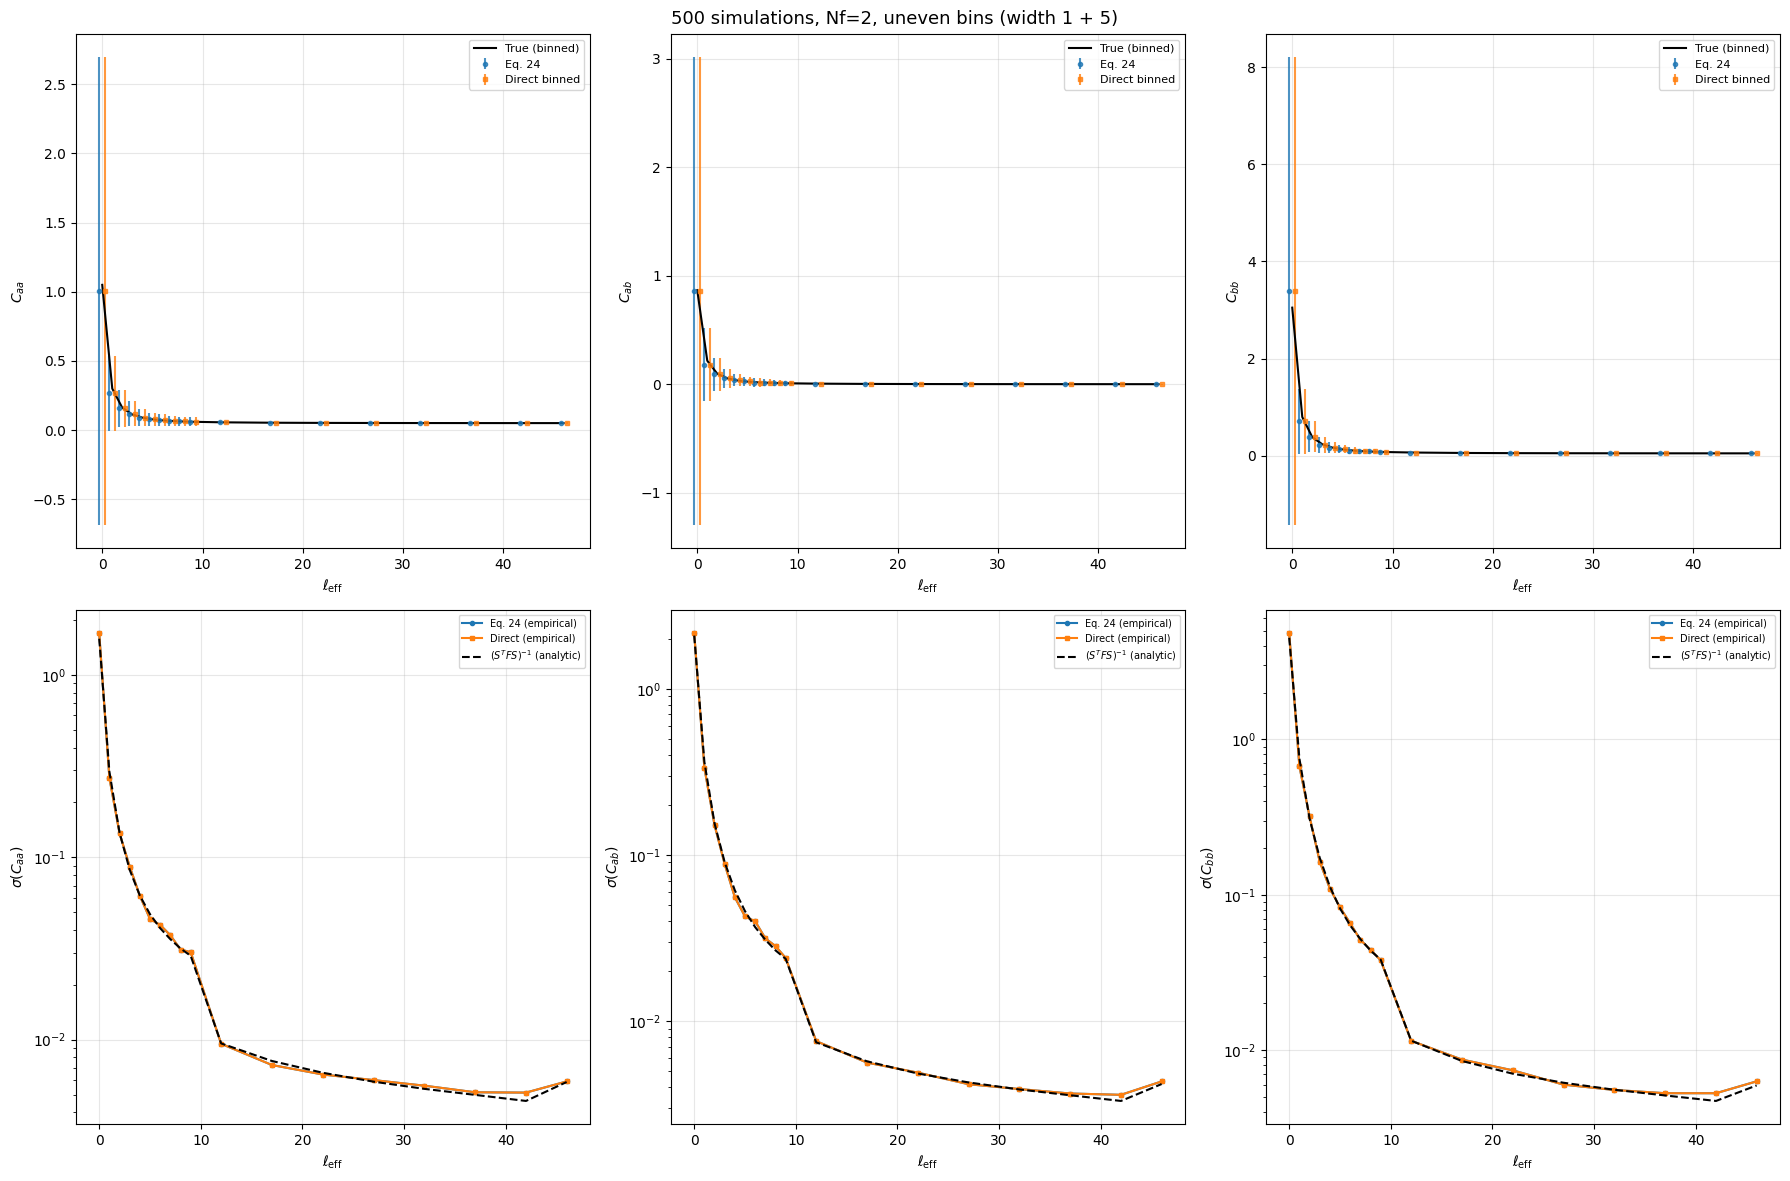

In [14]:
spectra = [
    (0, 0, C_aa_b, r'$C_{aa}$'),
    (0, 1, C_ab_b, r'$C_{ab}$'),
    (1, 1, C_bb_b, r'$C_{bb}$'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Analytic covariance is (S^T F S)^{-1} = F_b^{-1} for both routes
err_analytic = inv_Fb

for col, (fi, fj, C_true_b, label) in enumerate(spectra):
    idx = (F_idx_b[:, 0] == fi) & (F_idx_b[:, 1] == fj)

    mean_24 = c_mean_eq24[idx]
    mean_dir = c_mean_direct[idx]
    err_24 = np.sqrt(np.diag(c_cov_eq24)[idx])
    err_dir = np.sqrt(np.diag(c_cov_direct)[idx])
    err_an = np.sqrt(np.diag(err_analytic)[idx])

    dx = 0.3  # offset for visibility

    # Top: estimates
    ax = axes[0, col]
    ax.errorbar(ell_eff - dx, mean_24, yerr=err_24, fmt='o', ms=3,
                label='Eq. 24', alpha=0.8)
    ax.errorbar(ell_eff + dx, mean_dir, yerr=err_dir, fmt='s', ms=3,
                label='Direct binned', alpha=0.8)
    ax.plot(ell_eff, C_true_b, 'k-', lw=1.5, label='True (binned)')
    ax.set_xlabel(r'$\ell_{\rm eff}$')
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Bottom: error bars (analytic = (S^T F S)^{-1} for both)
    ax = axes[1, col]
    ax.semilogy(ell_eff, err_24, 'o-', ms=3, label='Eq. 24 (empirical)')
    ax.semilogy(ell_eff, err_dir, 's-', ms=3, label='Direct (empirical)')
    ax.semilogy(ell_eff, err_an, 'k--', lw=1.5, label=r'$(S^T F S)^{-1}$ (analytic)')
    ax.set_xlabel(r'$\ell_{\rm eff}$')
    ax.set_ylabel(f'$\\sigma$({label})')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle(f'{n_sims} simulations, Nf={Nf}, uneven bins (width 1 + 5)', fontsize=13)
plt.tight_layout()
plt.show()

### Ratio of error bars: eq. 24 vs direct

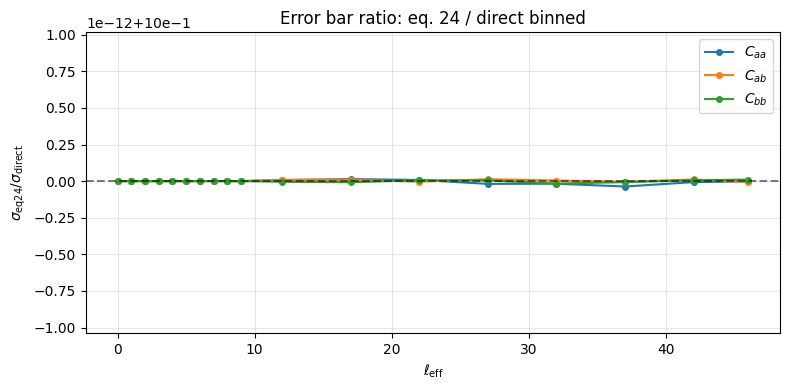

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for fi, fj, _, label in spectra:
    idx = (F_idx_b[:, 0] == fi) & (F_idx_b[:, 1] == fj)
    ratio = np.sqrt(np.diag(c_cov_eq24)[idx]) / np.sqrt(np.diag(c_cov_direct)[idx])
    ax.plot(ell_eff, ratio, 'o-', ms=4, label=label)

ax.axhline(1.0, color='k', ls='--', alpha=0.5)
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel(r'$\sigma_{\rm eq24} / \sigma_{\rm direct}$')
ax.set_title('Error bar ratio: eq. 24 / direct binned')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
ratio

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])